# Task 1 — Exploratory Data Analysis (EDA)
## Social Media, Dopamine and Productivity

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
path = r"C:\Users\mlacr\Downloads\social_media_dopamine_productivity.csv"
df = pd.read_csv(path, encoding='utf-8', low_memory=False)
df.head()

,participant_id,data_source,synthetic_flag,age,age_group,gender,race_ethnicity,nationality,country_of_residence,education_level,...,mood_dependency_on_sm,withdrawal_attempt_count,longest_detox_days,detox_relapse_reason,severity_stage,productivity_decline_score,dopamine_dysregulation_index,digital_wellbeing_score,sm_addiction_risk_score,notes
0,P0001,synthetic_ai,1,16,13-17,Female,South Asian,Indian,India,High school,...,Yes,9,2,3,Boredom,Critical,8.8,9.2,2.1,9.5
1,P0002,synthetic_ai,1,17,13-17,Male,East Asian,Chinese,China,High school,...,Yes,10,1,1,Curiosity,Critical,9.5,9.8,1.5,9.8
2,P0003,synthetic_ai,1,15,13-17,Female,Black/African,Nigerian,Nigeria,High school,...,Yes,8,2,5,Boredom,Severe,8.0,8.5,2.8,9.0
3,P0004,synthetic_ai,1,19,18-22,Male,White/Caucasian,American,USA,High school,...,Yes,9,3,7,Boredom,Severe,7.8,8.2,2.9,8.8
4,P0005,synthetic_ai,1,18,18-22,Female,Hispanic/Latino,Mexican,Mexico,High school,...,Yes,9,2,4,FOMO,Critical,9.0,9.3,2.0,9.6


In [20]:
# 2) Quick overview: info, shape
print(df.shape)
df.info()

(300, 66)
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 66 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   participant_id                    300 non-null    str    
 1   data_source                       300 non-null    str    
 2   synthetic_flag                    300 non-null    int64  
 3   age                               300 non-null    int64  
 4   age_group                         300 non-null    str    
 5   gender                            300 non-null    str    
 6   race_ethnicity                    300 non-null    str    
 7   nationality                       300 non-null    str    
 8   country_of_residence              300 non-null    str    
 9   education_level                   300 non-null    str    
 10  employment_status                 300 non-null    str    
 11  occupation_category               300 non-null    str    
 12  relations

In [21]:
# 3) Missing values and summary
missing = df.isna().sum().sort_values(ascending=False)
missing[missing>0]

# full descriptive table
pd.set_option('display.max_columns', None)
pd.set_option("display.max_rows", None)
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
participant_id,300,300,P0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
data_source,300,1,synthetic_ai,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
synthetic_flag,300.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
age,300.0,NaN,NaN,NaN,36.31,15.175029,15.0,24.0,33.5,46.25,75.0
age_group,300,7,36-49,74,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,300,3,Female,148,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race_ethnicity,300,7,White/Caucasian,72,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nationality,300,39,Indian,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country_of_residence,300,39,India,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,300,3,Undergraduate,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
# 5) Inspect top values for object columns (samples)
for col in df.columns:
    print(f"--- {col} ({df[col].nunique()} unique) ---")
    print(df[col].value_counts(dropna=False).head(10).to_string())
    print()



--- participant_id (300 unique) ---
participant_id
P0001    1
P0002    1
P0003    1
P0004    1
P0005    1
P0006    1
P0007    1
P0008    1
P0009    1
P0010    1

--- data_source (1 unique) ---
data_source
synthetic_ai    300

--- synthetic_flag (1 unique) ---
synthetic_flag
1    300

--- age (61 unique) ---
age
25    12
21    10
20    10
22    10
27    10
19     9
26     9
16     8
17     8
18     8

--- age_group (7 unique) ---
age_group
36-49    74
28-35    53
18-22    50
23-27    43
50-59    35
60+      27
13-17    18

--- gender (3 unique) ---
gender
Female        148
Male          145
Non-binary      7

--- race_ethnicity (7 unique) ---
race_ethnicity
White/Caucasian    72
East Asian         63
Black/African      54
South Asian        52
Hispanic/Latino    43
Middle Eastern     15
Native American     1

--- nationality (39 unique) ---
nationality
Indian          26
American        24
Nigerian        15
Chinese         14
Mexican         12
Pakistani       12
British         12
Aus

Due to the large number of variables in the dataset we are going to focus the EDA in the following selection:

- Concerning demographics: `age`, `age_group`, `gender`, `education_level` and `employment_status`.
- Concerning social media use: `avg_daily_sm_hours`, `years_on_social_media`, `primary_platform`, `daily_check_frequency`, `late_night_scrolling`, `sm_during_work_study`, `doomscrolling_frequency`.
- Concerning dopamine boosting and dependency related behaviour: `dopamine_rush_feel_score`, `fomo_score`, `validation_seeking_score`,`boredom_to_phone_reflex`, `inability_to_delay_gratification`, `mood_dependency_on_sm`.
- Concerning productivity: `attention_span_minutes`, `deep_work_duration_minutes`, `productivity_self_rating`, `creative_output_frequency`,`learning_retention_difficulty`, `reading_duration_minutes_per_day`.
- Other potentially relevant variables: `avg_sleep_hours`, `sleep_quality`,`exercise_frequency`.

The selected variables allow us to explore the relationship between social media use, dopamine-related behaviours, and productivity, while considering demographic and lifestyle factors that may be associated with these patterns.
This selection allows us to keep the EDA focused and manageable.

In [23]:
df=df.drop(columns=[col for col in df.columns if col not in ["age", "age_group", "gender", "education_level", "employment_status",
"avg_daily_sm_hours", "years_on_social_media", "primary_platform", "daily_check_frequency", "late_night_scrolling", 
"sm_during_work_study",  "doomscrolling_frequency",
"dopamine_rush_feel_score", "fomo_score", "validation_seeking_score","boredom_to_phone_reflex", "inability_to_delay_gratification", 
"mood_dependency_on_sm","attention_span_minutes", "deep_work_duration_minutes", "productivity_self_rating", 
 "creative_output_frequency","learning_retention_difficulty", "reading_duration_minutes_per_day","avg_sleep_hours", 
 "sleep_quality","exercise_frequency"
]],
          errors="ignore")

In [24]:
categorical = set(df.select_dtypes(include=["object", "str"]).columns)

units = {
    "age": "years",
    "avg_daily_sm_hours": "hours/day",
    "years_on_social_media": "years",
    "avg_daily_screen_time_hours": "hours/day",
    "avg_sleep_hours": "hours/night",
    "avg_work_study_hours_per_day": "hours/day",
    "dopamine_rush_feel_score": "1–10 score",
    "reward_seeking_behavior": "1–10 score",
    "fomo_score": "1–10 score",
    "validation_seeking_score": "1–10 score",
    "attention_span_minutes": "minutes",
    "deep_work_duration_minutes": "minutes",
    "productivity_self_rating": "1–10 score",
    "reading_duration_minutes_per_day": "minutes/day",
 
}

datatype ={
    "age": "Numerical discrete", 
    "age_group": "Categorical ordinal", 
    "gender": "Categorical nominal", 
    "education_level": "Categorical nominal", 
    "employment_status": "Categorical nominal",
    "avg_daily_sm_hours": "Numerical discrete",
    "years_on_social_media": "Numerical discrete",
    "primary_platform": "Categorical nominal",
    "daily_check_frequency": "Categorical ordinal",
    "late_night_scrolling": "Categorical ordinal",
    "sm_during_work_study": "Categorical ordinal",
    "doomscrolling_frequency": "Categorical ordinal",
    "dopamine_rush_feel_score": "Numerical discrete",
    "fomo_score": "Numerical discrete",
    "validation_seeking_score": "Numerical discrete",
    "boredom_to_phone_reflex": "Categorical ordinal",
    "inability_to_delay_gratification": "Categorical ordinal",
    "mood_dependency_on_sm": "Categorical ordinal",
    "attention_span_minutes": "Numerical discrete",
    "deep_work_duration_minutes": "Numerical discrete",
    "productivity_self_rating": "Numerical discrete",
    "creative_output_frequency": "Categorical nominal",
    "learning_retention_difficulty": "Categorical nominal",
    "reading_duration_minutes_per_day": "Numerical discrete",
    "avg_sleep_hours": "Numerical discrete",
    "sleep_quality": "Categorical ordinal",
    "exercise_frequency": "Categorical ordinal"

}



def temporal_geo(c):
    return "Geographic" if c in {"country_of_residence", "nationality"} else "No"

def domain(c):
    s = df[c]
    if c in categorical:
        n = s.dropna().nunique()
        if n <= 12:
            return ", ".join(map(str, sorted(s.dropna().unique())))
        return f"{n} distinct categories"
    return f"{s.min():g} to {s.max():g}"

metadata_rows = []
for c in df.columns:
    metadata_rows.append({
        "Field": c,
        "Data type": df[c].dtype.name,
        "Kind": datatype.get(c),
        "Temporal / geographic...": temporal_geo(c),
        "Domain / range": domain(c),
        "Unit / precision": units.get(c, "Category label" if c in categorical else "Numeric value; precision as stored"),
        "Missing": int(df[c].isna().sum()),
        "Unique": int(df[c].nunique(dropna=True)),
    })

field_dictionary = pd.DataFrame(metadata_rows)


In [25]:
from IPython.display import display, HTML

html_table = field_dictionary.to_html(
    index=False,
    classes="dataframe",
    escape=False
)

display(HTML(f"""
<div style="
    max-height: 500px;
    overflow: auto;
    border: 1px solid #ddd;
">
    {html_table}
</div>
"""))

Field,Data type,Kind,Temporal / geographic...,Domain / range,Unit / precision,Missing,Unique
age,int64,Numerical discrete,No,15 to 75,years,0,61
age_group,str,Categorical ordinal,No,"13-17, 18-22, 23-27, 28-35, 36-49, 50-59, 60+",Category label,0,7
gender,str,Categorical nominal,No,"Female, Male, Non-binary",Category label,0,3
education_level,str,Categorical nominal,No,"High school, Postgraduate, Undergraduate",Category label,0,3
employment_status,str,Categorical nominal,No,"Freelancer, Full-time employed, Job seeker, Part-time employed, Retired, Self-employed, Student",Category label,0,7
avg_daily_sm_hours,float64,Numerical discrete,No,0.5 to 9,hours/day,0,18
years_on_social_media,int64,Numerical discrete,No,3 to 14,years,0,12
primary_platform,str,Categorical nominal,No,"Douyin/TikTok, Facebook, Instagram, LinkedIn, Reddit, TikTok, Twitter/X, WeChat, YouTube",Category label,0,9
daily_check_frequency,str,Categorical ordinal,No,"2-3 times a day, Constantly, Every few hours, Once a day, Once a week",Category label,0,5
late_night_scrolling,str,Categorical ordinal,No,"Daily, Never, Often, Rarely, Sometimes",Category label,0,5


## Chart 1  Distribution of average daily social media use

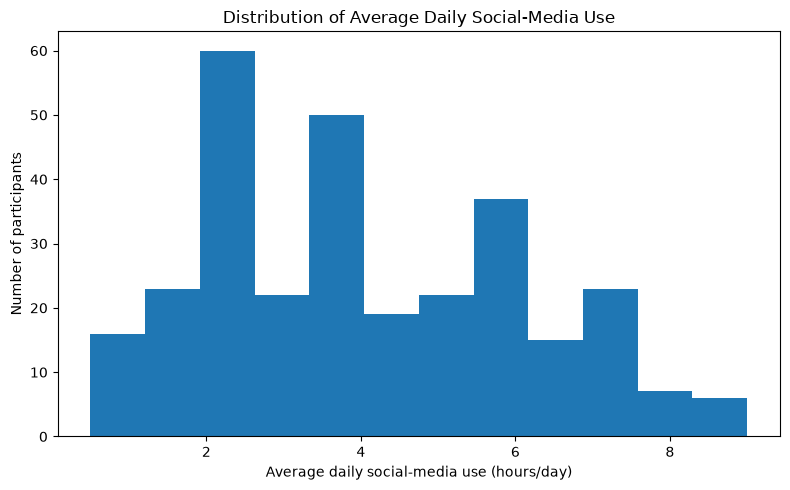

In [26]:
plt.figure(figsize=(8, 5))
plt.hist(df["avg_daily_sm_hours"], bins=12)
plt.xlabel("Average daily social-media use (hours/day)")
plt.ylabel("Number of participants")
plt.title("Distribution of Average Daily Social-Media Use")
plt.tight_layout()
plt.show()

## Chart 2 Sleep quality and late night scrolling

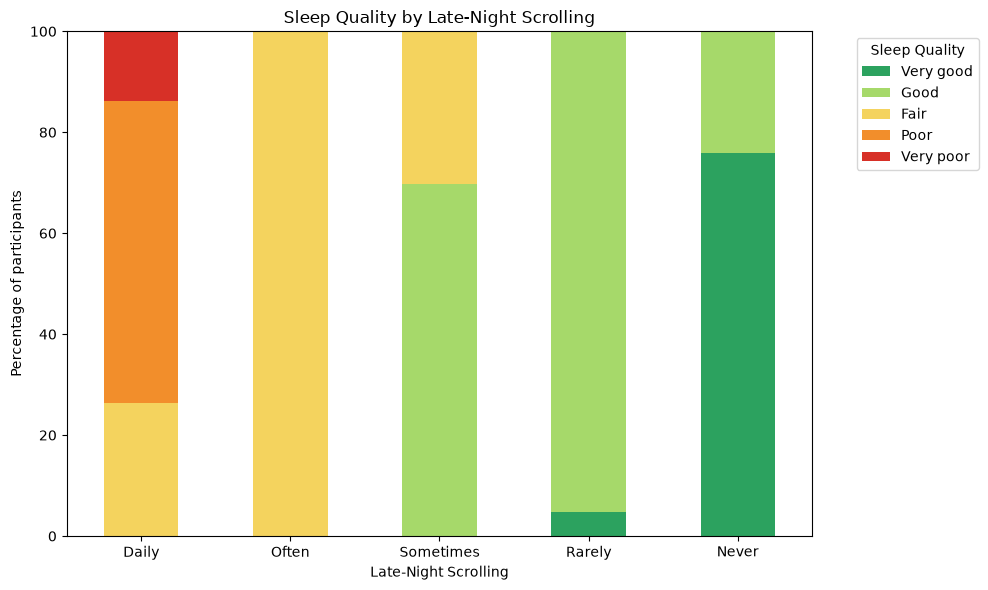

In [27]:
sleep_quality_by_scrolling = pd.crosstab(
    df["late_night_scrolling"],
    df["sleep_quality"],
    normalize="index"
) * 100

# keep the order as: very good -> good -> fair -> poor -> very poor
quality_order = ["Very good", "Good", "Fair", "Poor", "Very poor"]
late_night_order = ["Daily", "Often", "Sometimes", "Rarely", "Never"]

sleep_quality_by_scrolling = sleep_quality_by_scrolling.reindex(
    index=late_night_order,
    columns=quality_order,
    fill_value=0
)

# green to red gradient, best to worst
quality_colors = ["#2ca25f", "#a6d96a", "#f4d35e", "#f28e2b", "#d73027"]

ax = sleep_quality_by_scrolling.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=quality_colors
)

plt.title("Sleep Quality by Late-Night Scrolling")
plt.xlabel("Late-Night Scrolling")
plt.ylabel("Percentage of participants")
plt.legend(
    title="Sleep Quality",
    labels=quality_order,
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Chart 3 Doomscrolling frequency and creative output 

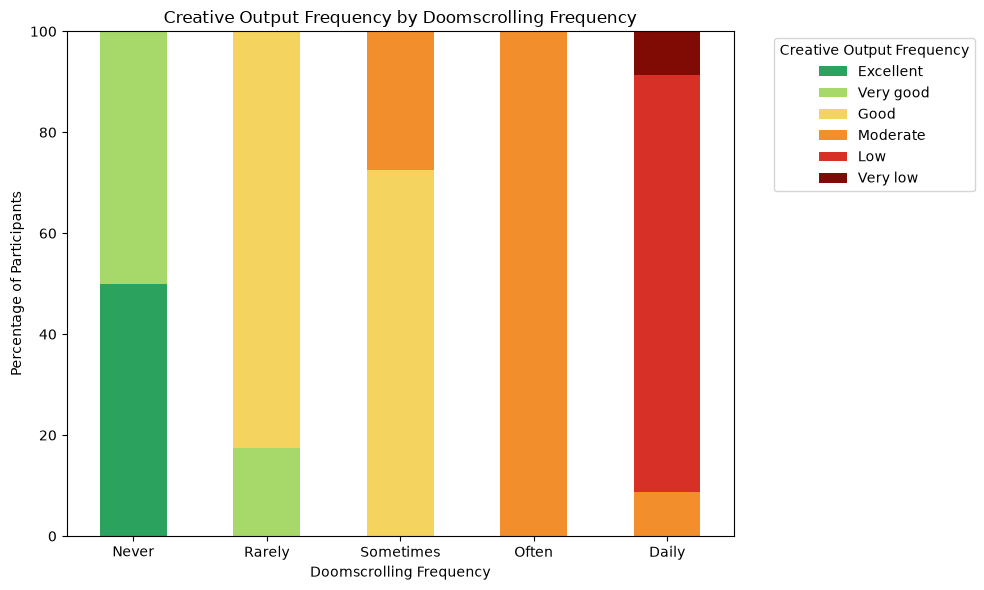

In [28]:
creative_by_doomscrolling = pd.crosstab(
    df["doomscrolling_frequency"],
    df["creative_output_frequency"],
    normalize="index"
) * 100

doomscroll_order = ["Never", "Rarely", "Sometimes", "Often", "Daily"]
creative_order = ["Excellent", "Very good", "Good", "Moderate", "Low", "Very low"]

creative_by_doomscrolling = creative_by_doomscrolling.reindex(
    index=doomscroll_order,
    columns=creative_order,
    fill_value=0
)

creative_colors = ["#2ca25f", "#a6d96a", "#f4d35e", "#f28e2b", "#d73027", "#800a04"]

ax = creative_by_doomscrolling.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=creative_colors
)

plt.title("Creative Output Frequency by Doomscrolling Frequency")
plt.xlabel("Doomscrolling Frequency")
plt.ylabel("Percentage of Participants")
plt.legend(
    title="Creative Output Frequency",
    labels=creative_order,
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Chart 4 Average social media hours and attention span minutes

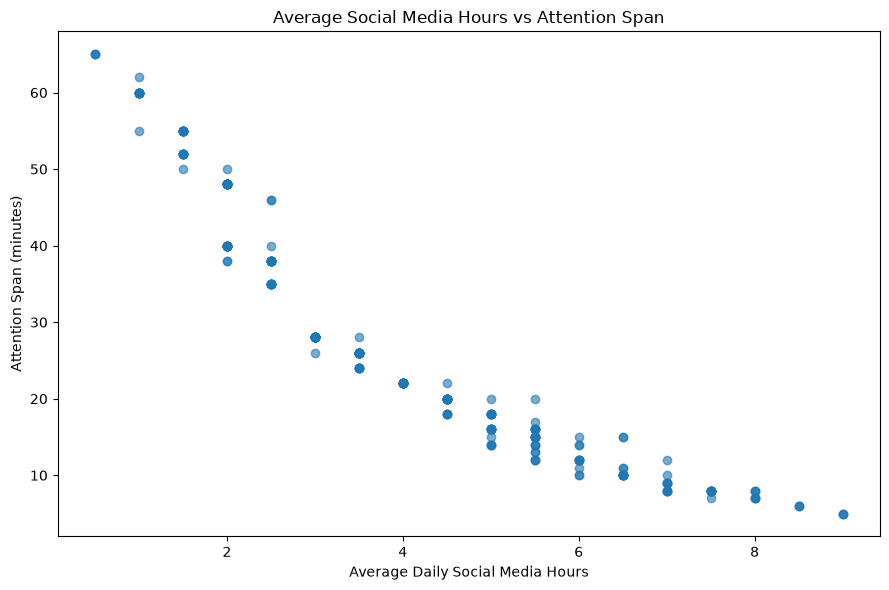

In [29]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["avg_daily_sm_hours"],
    df["attention_span_minutes"],
    alpha=0.6
)

plt.title("Average Social Media Hours vs Attention Span")
plt.xlabel("Average Daily Social Media Hours")
plt.ylabel("Attention Span (minutes)")
plt.tight_layout()
plt.show()

## Chart 5 Years in social media, average number of hours in social media and main platform

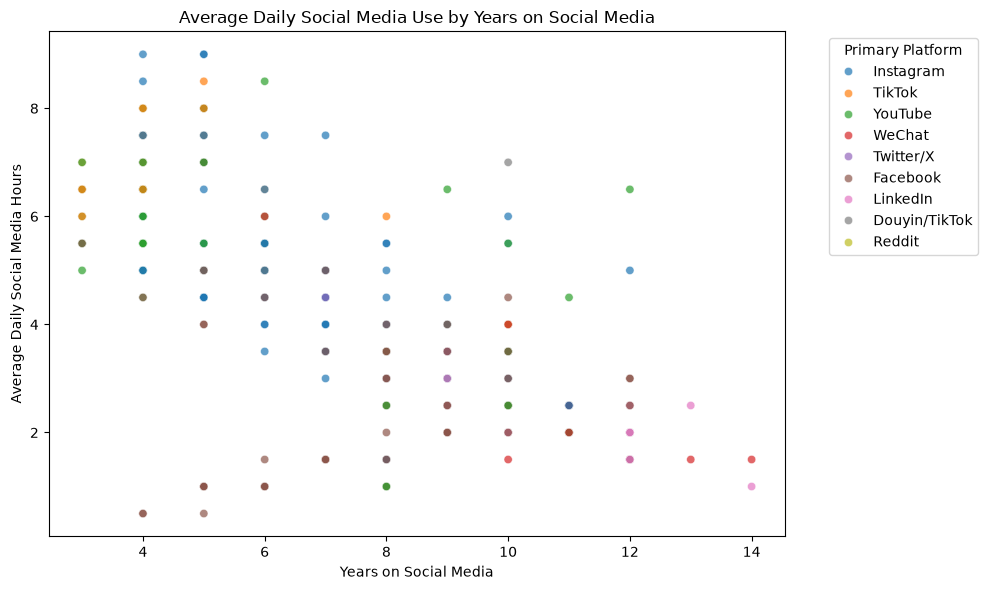

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="years_on_social_media",
    y="avg_daily_sm_hours",
    hue="primary_platform",
    alpha=0.7
)

plt.title("Average Daily Social Media Use by Years on Social Media")
plt.xlabel("Years on Social Media")
plt.ylabel("Average Daily Social Media Hours")
plt.legend(title="Primary Platform", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Chart 6 Validation seeking score, age group and gender

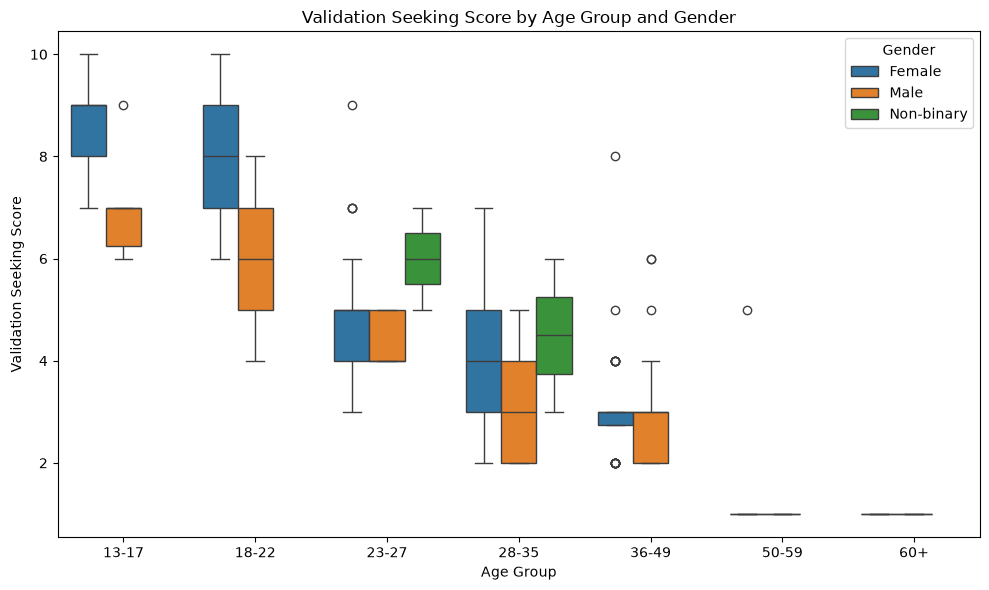

In [31]:
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="age_group",
    y="validation_seeking_score",
    hue="gender"
)

plt.title("Validation Seeking Score by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("Validation Seeking Score")
plt.legend(title="Gender")

plt.tight_layout()
plt.show()

## Chart 7 Daily social media use and deep work duration

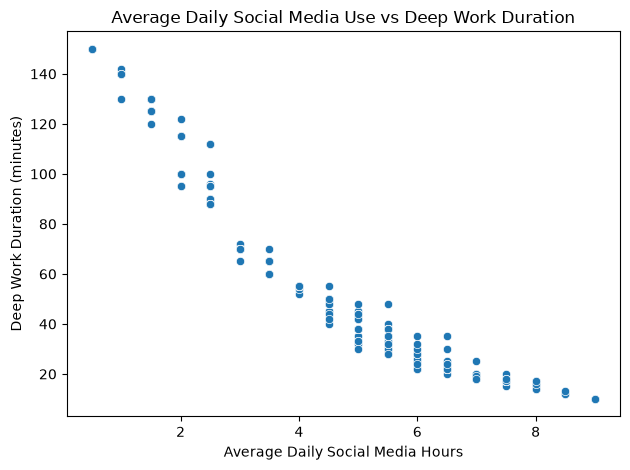

In [32]:
sns.scatterplot(
    data=df,
    x="avg_daily_sm_hours",
    y="deep_work_duration_minutes"
)

plt.title("Average Daily Social Media Use vs Deep Work Duration")
plt.xlabel("Average Daily Social Media Hours")
plt.ylabel("Deep Work Duration (minutes)")
plt.tight_layout()
plt.show()

## Chart 7 Social media, productivity and behaviour

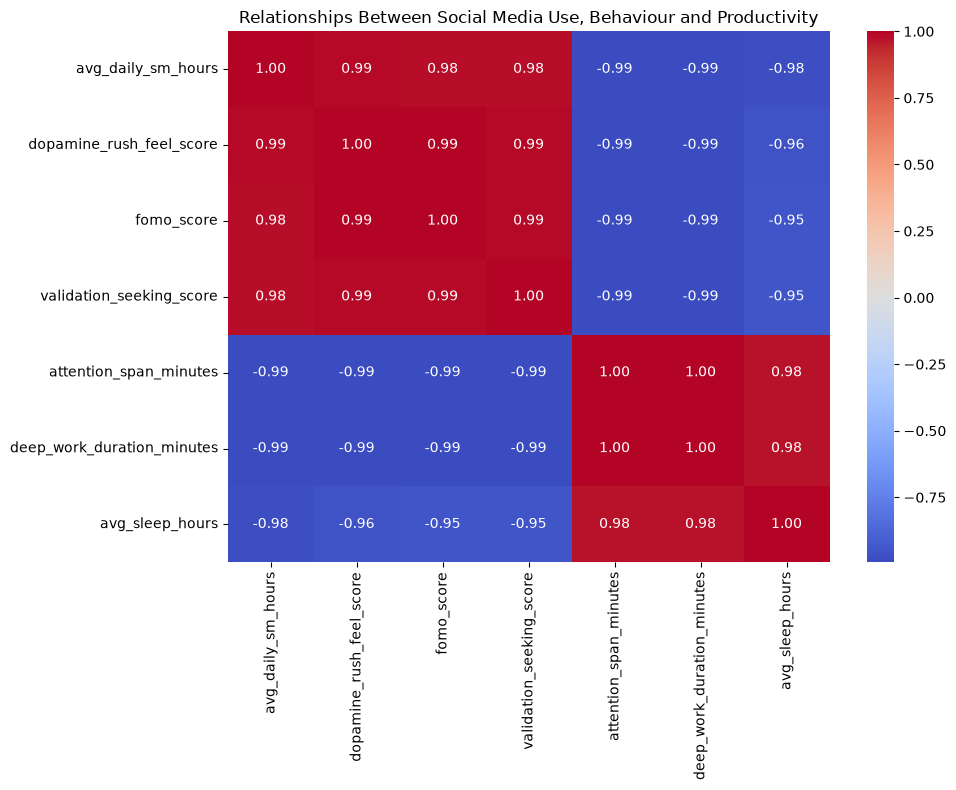

In [33]:
variables_numeric = [
    "avg_daily_sm_hours",
    "dopamine_rush_feel_score",
    "fomo_score",
    "validation_seeking_score",
    "attention_span_minutes",
    "deep_work_duration_minutes",
    "avg_sleep_hours"
]

corr = df[variables_numeric].corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Relationships Between Social Media Use, Behaviour and Productivity")
plt.tight_layout()
plt.show()

## Social media and sleep hours

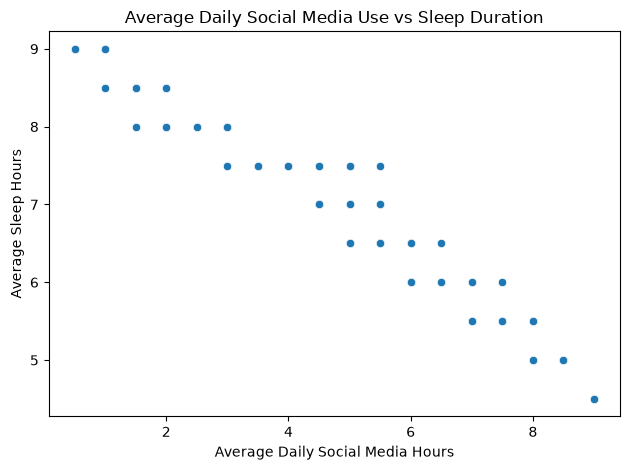

In [34]:
sns.scatterplot(
    data=df,
    x="avg_daily_sm_hours",
    y="avg_sleep_hours"
)

plt.title("Average Daily Social Media Use vs Sleep Duration")
plt.xlabel("Average Daily Social Media Hours")
plt.ylabel("Average Sleep Hours")
plt.tight_layout()
plt.show()

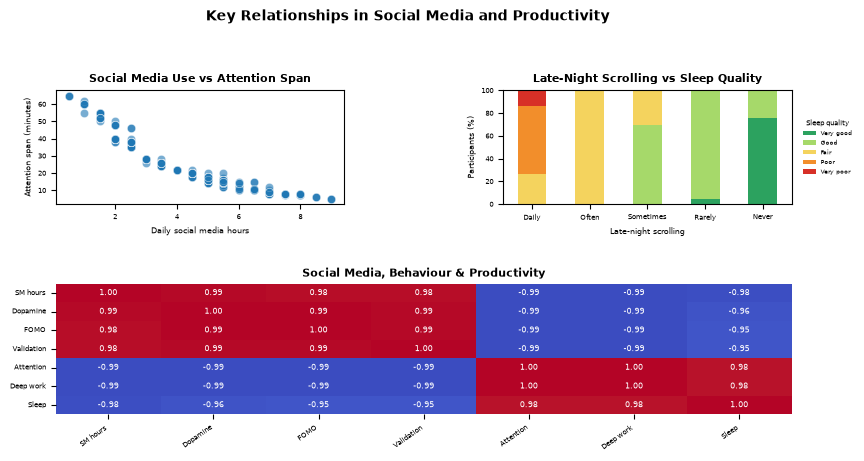

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================
# Create an 800 x 450 pixel figure
# =========================================================

fig = plt.figure(figsize=(8, 4.5), dpi=100)

# 2x2 layout:
# - Top left: Social Media Use vs Attention Span
# - Top right: Late-Night Scrolling vs Sleep Quality
# - Bottom: Heatmap
gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1, 1.15],
    hspace=0.65,
    wspace=0.55
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])


# =========================================================
# 1. Social Media Use vs Attention Span
# =========================================================

sns.scatterplot(
    data=df,
    x="avg_daily_sm_hours",
    y="attention_span_minutes",
    alpha=0.6,
    ax=ax1
)

ax1.set_title(
    "Social Media Use vs Attention Span",
    fontsize=8,
    fontweight="bold"
)

ax1.set_xlabel(
    "Daily social media hours",
    fontsize=6
)

ax1.set_ylabel(
    "Attention span (minutes)",
    fontsize=6
)

ax1.tick_params(axis="both", labelsize=5)


# =========================================================
# 2. Late-Night Scrolling vs Sleep Quality
# =========================================================

sleep_quality_by_scrolling = pd.crosstab(
    df["late_night_scrolling"],
    df["sleep_quality"],
    normalize="index"
) * 100

# Keep the order:
# Very good -> Good -> Fair -> Poor -> Very poor
quality_order = [
    "Very good",
    "Good",
    "Fair",
    "Poor",
    "Very poor"
]

# Keep the order:
# Daily -> Often -> Sometimes -> Rarely -> Never
late_night_order = [
    "Daily",
    "Often",
    "Sometimes",
    "Rarely",
    "Never"
]

sleep_quality_by_scrolling = sleep_quality_by_scrolling.reindex(
    index=late_night_order,
    columns=quality_order,
    fill_value=0
)

# Green -> red gradient
quality_colors = [
    "#2ca25f",
    "#a6d96a",
    "#f4d35e",
    "#f28e2b",
    "#d73027"
]

sleep_quality_by_scrolling.plot(
    kind="bar",
    stacked=True,
    ax=ax2,
    color=quality_colors
)

ax2.set_title(
    "Late-Night Scrolling vs Sleep Quality",
    fontsize=8,
    fontweight="bold"
)

ax2.set_xlabel(
    "Late-night scrolling",
    fontsize=6
)

ax2.set_ylabel(
    "Participants (%)",
    fontsize=6
)

ax2.tick_params(axis="both", labelsize=5)

ax2.set_xticklabels(
    ax2.get_xticklabels(),
    rotation=0
)

# Legend to the RIGHT of the graph, vertically
ax2.legend(
    title="Sleep quality",
    labels=quality_order,
    fontsize=4.5,
    title_fontsize=5,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)


# =========================================================
# 3. Social Media, Behaviour & Productivity
#    Spearman correlation heatmap
# =========================================================

variables_numeric = [
    "avg_daily_sm_hours",
    "dopamine_rush_feel_score",
    "fomo_score",
    "validation_seeking_score",
    "attention_span_minutes",
    "deep_work_duration_minutes",
    "avg_sleep_hours"
]

corr = df[variables_numeric].corr(method="spearman")

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    cbar=False,
    ax=ax3,
    annot_kws={"fontsize": 6}
)

ax3.set_title(
    "Social Media, Behaviour & Productivity",
    fontsize=8,
    fontweight="bold",
    pad=5
)

# Shorter labels for readability
short_labels = [
    "SM hours",
    "Dopamine",
    "FOMO",
    "Validation",
    "Attention",
    "Deep work",
    "Sleep"
]

ax3.set_xticklabels(
    short_labels,
    rotation=35,
    ha="right",
    fontsize=5
)

ax3.set_yticklabels(
    short_labels,
    rotation=0,
    fontsize=5
)


# =========================================================
# Main title
# =========================================================

fig.suptitle(
    "Key Relationships in Social Media and Productivity",
    fontsize=10,
    fontweight="bold",
    y=0.98
)


# =========================================================
# Final layout
# =========================================================

plt.subplots_adjust(
    top=0.80,
    bottom=0.08,
    left=0.06,
    right=0.98,
    hspace=0.65,
    wspace=0.55
)


# =========================================================
# Save EXACTLY as 800 x 450 pixels
# =========================================================

plt.savefig(
    "task01.png",
    dpi=100
)

plt.show()